<a href="https://colab.research.google.com/github/priyanka287-agrawal/Air-pollutants-AQI-prediction/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Air Quality Visualization and Forecasting of Air Quality Index Using a Hybrid Machine Learning Model (Random Forest, XGBoost, LSTM with ARIMA Residual Modelling)***

**Author** : **Priyanka**

Department of Applied Mathematics ,KIIT University

Degree : Msc Mathematics and Data science

Guide : Dr. vishal pradhan


IMPLEMENTING MODEL IN PYTHON:

Reference Paper: Anuradha Yenkikar,Ved Prakash Mishra,Manish Bali,Tabassum Ara "Explainable forecasting of air quality index using a hybrid random forest and ARIMA model Volume15(2025)" 103517

KEY IDEA:

The project proposes a hybrid AQI forecasting framework integrating Random Forest, XGBoost, LSTM, and ARIMA models to improve air quality prediction accuracy. Pollutant concentrations are first predicted using XGBoost, followed by ensemble AQI prediction and ARIMA-based residual correction. SHAP analysis is further applied to interpret the contribution of individual pollutants to AQI predictions.

RESULTS after IMPLEMENTATION:

The hybrid model demonstrated improved forecasting performance with lower prediction errors and higher R² values compared to individual models. Ensemble averaging effectively reduced model bias and variance, while ARIMA residual modeling captured remaining temporal dependencies. SHAP analysis revealed that PM2.5 and PM10 were the most influential pollutants affecting AQI levels.





# importing files

In [ ]:
import pandas as pd

# Load the new file
file_path_br005 = "/final_pollution_with_cpcb_aqi (br005).xlsx"
df_br005 = pd.read_excel(file_path_br005)

# Display the first 5 rows to verify
print(f"Successfully loaded {file_path_br005}. First 5 rows:")
display(df_br005.head())

Successfully loaded /final_pollution_with_cpcb_aqi (br005).xlsx. First 5 rows:


,From Date,year,month,day,hour,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,AQI_RF,AQI_XGB,AQI_LSTM,PM2.5_index,PM10_index,NO2_index,SO2_index,CO_index,O3_index,AQI_CPCB
0,2023-04-02 00:00:00,2023,4,2,0,135.795883,353.007202,32.119175,10.129910,0.945923,...,312.09,312.102203,168.58767,312.354980,303.515355,40.148969,12.662388,47.296154,0.0,312.354980
1,2023-04-02 01:00:00,2023,4,2,1,134.497513,360.326630,22.433096,9.418898,1.006262,...,315.26,315.647156,169.58767,311.358556,312.687802,28.041370,11.773622,45.896490,0.0,312.687802
2,2023-04-02 02:00:00,2023,4,2,2,133.544113,306.209381,23.371714,9.774188,1.004163,...,311.00,310.627380,170.58767,310.626878,256.209381,29.214642,12.217735,45.782203,0.0,310.626878
3,2023-04-02 03:00:00,2023,4,2,3,134.276917,296.918152,18.740973,9.777346,0.897981,...,311.00,311.630402,171.58767,311.189262,246.918152,23.426216,12.221682,44.899040,0.0,311.189262
4,2023-04-02 04:00:00,2023,4,2,4,114.985519,291.229095,16.918516,9.041336,0.956311,...,283.00,284.522949,172.58767,282.881601,241.229095,21.148145,11.301670,47.815570,0.0,282.881601


In [1]:
import pandas as pd

# Replace with your actual file path
file_path = "/final_pollution_with_cpcb_aqi (dl030).xlsx"
df = pd.read_excel(file_path)

# Display the first 5 rows to verify
print(f"Successfully loaded {file_path}. First 5 rows:")
display(df.head())



Successfully loaded /final_pollution_with_cpcb_aqi (dl030).xlsx. First 5 rows:


,From Date,year,month,day,hour,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,AQI_XGB,AQI_LSTM,PM2.5_index,PM10_index,NO2_index,SO2_index,CO_index,O3_index,AQI_CPCB,Ensemble_AQI
0,2023-04-02 00:00:00,2023,4,2,0,89.620338,310.756561,35.147305,10.746246,1.058147,...,262.021759,69.340774,198.703914,260.756561,43.934131,13.432808,48.721315,5.161453,260.756561,197.454178
1,2023-04-02 01:00:00,2023,4,2,1,89.344490,279.777679,34.031788,10.777308,0.879659,...,230.551285,70.340774,197.762225,229.777679,42.539735,13.471634,43.982950,5.161453,229.777679,176.964020
2,2023-04-02 02:00:00,2023,4,2,2,92.964775,266.718781,30.683870,11.174823,0.912081,...,219.512405,71.340774,207.707336,216.718781,38.354838,13.968529,45.604047,4.660219,216.718781,169.281060
3,2023-04-02 03:00:00,2023,4,2,3,93.424706,242.089447,31.990612,10.542816,0.835435,...,205.012711,72.340774,209.277443,194.743995,39.988265,13.178520,41.771773,3.740668,209.277443,162.384495
4,2023-04-02 04:00:00,2023,4,2,4,87.284531,242.830231,33.149818,10.697456,0.875468,...,198.457275,73.340774,190.729949,195.236194,41.437273,13.371820,43.773425,2.937582,195.236194,155.612683


In [2]:
import pandas as pd

# Replace with your actual file path
file_path = "/final_pollution_with_cpcb_aqi(dl024).xlsx"
df = pd.read_excel(file_path)

# Display the first 5 rows to verify
print(f"Successfully loaded {file_path}. First 5 rows:")
display(df.head())


Successfully loaded /final_pollution_with_cpcb_aqi(dl024).xlsx. First 5 rows:


,From Date,year,month,day,hour,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,AQI_XGB,AQI_LSTM,PM2.5_index,PM10_index,NO2_index,SO2_index,CO_index,O3_index,AQI_CPCB,Ensemble_AQI
0,2023-04-02 00:00:00,2023,4,2,0,130.329956,404.579803,26.739998,12.421543,1.567470,...,365.319946,320.46831,308.160199,368.144311,33.424997,15.526929,76.451148,1.845899,368.144311,351.299419
1,2023-04-02 01:00:00,2023,4,2,1,137.277328,386.921539,26.739998,12.817070,1.538002,...,347.191864,321.46831,313.491903,346.015600,33.424997,16.021338,74.846763,4.048295,346.015600,338.220058
2,2023-04-02 02:00:00,2023,4,2,2,135.156097,354.017487,26.739998,11.622004,1.230831,...,312.438965,322.46831,311.863982,304.781407,33.424997,14.527504,58.123029,4.555088,311.863982,315.639092
3,2023-04-02 03:00:00,2023,4,2,3,145.286011,345.341034,26.739998,12.988570,1.292496,...,319.276520,323.46831,319.638101,295.341034,33.424997,16.235713,61.480355,5.442607,319.638101,320.914943
4,2023-04-02 04:00:00,2023,4,2,4,163.758545,352.541718,26.739998,13.122147,1.271678,...,334.103455,324.46831,333.814697,302.932026,33.424997,16.402683,60.346892,5.511263,333.814697,330.857255


In [ ]:
from google.colab import files

files.download("cityday_filled_O3.xlsx")

In [ ]:
!pip install pmdarima


## Correlation Matrix

The correlation matrix was used to analyze the relationship between different cities of delhi and  patna and also different pollutants and the Air Quality Index (AQI) in the dataset. It helped identify the strength and direction of linear relationships among variables using Pearson’s correlation coefficient. Through the heatmap visualization, highly correlated pollutants such as PM2.5 and PM10 etc. The analysis also assisted in understanding feature dependency, reducing redundancy, and selecting relevant variables for machine learning model development.

In [ ]:
print('DataFrame Info:')
df.info()

print('\nDataFrame dtypes:')
print(df.dtypes)

                  anand   rkpuram       igi   punjabi  lodhi_road  \
anand          1.000000 -0.155578 -0.139288  0.032763   -0.064870   
rkpuram       -0.155578  1.000000  0.072454  0.151681    0.126642   
igi           -0.139288  0.072454  1.000000  0.052186    0.328493   
punjabi        0.032763  0.151681  0.052186  1.000000    0.070259   
lodhi_road    -0.064870  0.126642  0.328493  0.070259    1.000000   
chandni_chowk -0.065119  0.105219  0.313982  0.058276    0.509807   
rohini        -0.069481  0.051401  0.257876 -0.005515    0.132529   
dwarka        -0.062369  0.083360  0.173152  0.025357    0.053943   
patna          0.309147  0.000101 -0.296007  0.180772   -0.156623   

               chandni_chowk    rohini    dwarka     patna  
anand              -0.065119 -0.069481 -0.062369  0.309147  
rkpuram             0.105219  0.051401  0.083360  0.000101  
igi                 0.313982  0.257876  0.173152 -0.296007  
punjabi             0.058276 -0.005515  0.025357  0.180772  
lodh

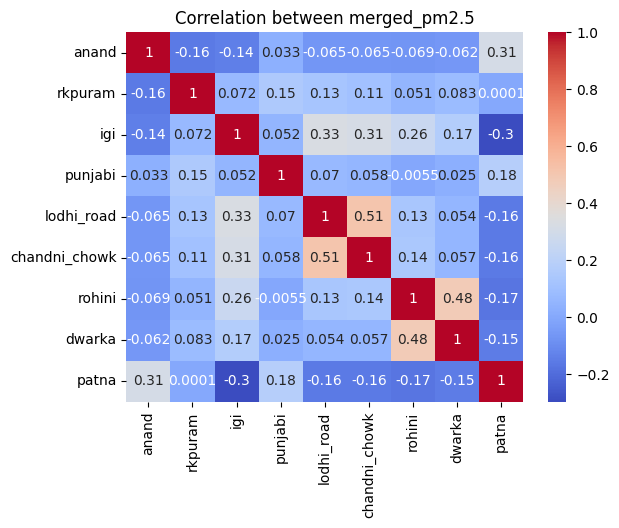

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/merged_p2.5.xlsx")

#selct relevant numeric columns
column_to_compare=['anand','rkpuram','igi','punjabi','lodhi_road','chandni_chowk','rohini','dwarka','patna']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between merged_pm2.5")
plt.show()



In [ ]:
from google.colab import files

files.download("your_output_file_with_moving_avg_filled.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/BR005_FILLED_AQI.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)','NOx (ppb)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

                 PM2.5 (ug/m3)  PM10 (ug/m3)  NO2 (ug/m3)  NO (ug/m3)  \
PM2.5 (ug/m3)         1.000000      0.857557     0.478488    0.510731   
PM10 (ug/m3)          0.857557      1.000000     0.561476    0.579467   
NO2 (ug/m3)           0.478488      0.561476     1.000000    0.524588   
NO (ug/m3)            0.510731      0.579467     0.524588    1.000000   
NH3 (ug/m3)           0.425441      0.372726     0.102207    0.176700   
SO2 (ug/m3)           0.264378      0.311643     0.399970    0.096386   
CO (mg/m3)            0.570191      0.624886     0.600888    0.802188   
Ozone (ug/m3)        -0.137068     -0.063156    -0.141919   -0.197536   
Benzene (ug/m3)       0.118251      0.121023     0.181024    0.111589   
Toluene (ug/m3)       0.248067      0.263696     0.413633    0.337812   
RH (%)                0.171447      0.018631    -0.093220    0.175807   
WS (m/s)             -0.344383     -0.295638    -0.316807   -0.324054   
WD (degree)           0.126143      0.098006    -0.

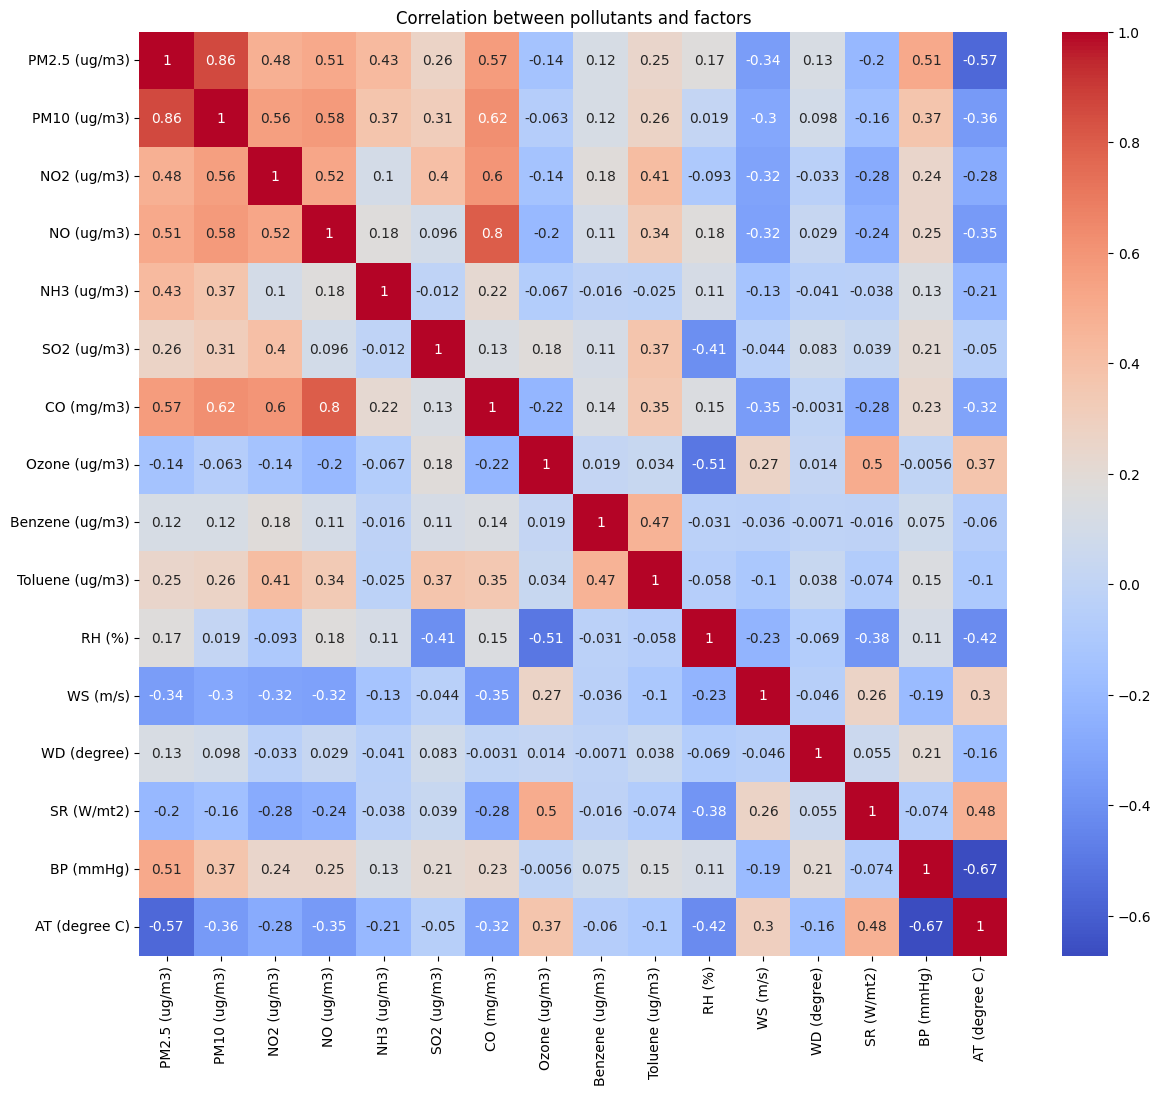

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/DL024_FILLED_2023_AQI_NEW.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

                 PM2.5 (ug/m3)  PM10 (ug/m3)  NO2 (ug/m3)  NO (ug/m3)  \
PM2.5 (ug/m3)         1.000000      0.857557     0.478488    0.510731   
PM10 (ug/m3)          0.857557      1.000000     0.561476    0.579467   
NO2 (ug/m3)           0.478488      0.561476     1.000000    0.524588   
NO (ug/m3)            0.510731      0.579467     0.524588    1.000000   
NOx (ppb)             0.555431      0.628951     0.607132    0.978287   
NH3 (ug/m3)           0.425441      0.372726     0.102207    0.176700   
SO2 (ug/m3)           0.264378      0.311643     0.399970    0.096386   
CO (mg/m3)            0.570191      0.624886     0.600888    0.802188   
Ozone (ug/m3)        -0.137068     -0.063156    -0.141919   -0.197536   
Benzene (ug/m3)       0.118251      0.121023     0.181024    0.111589   
Toluene (ug/m3)       0.248067      0.263696     0.413633    0.337812   
RH (%)                0.171447      0.018631    -0.093220    0.175807   
WS (m/s)             -0.344383     -0.295638    -0.

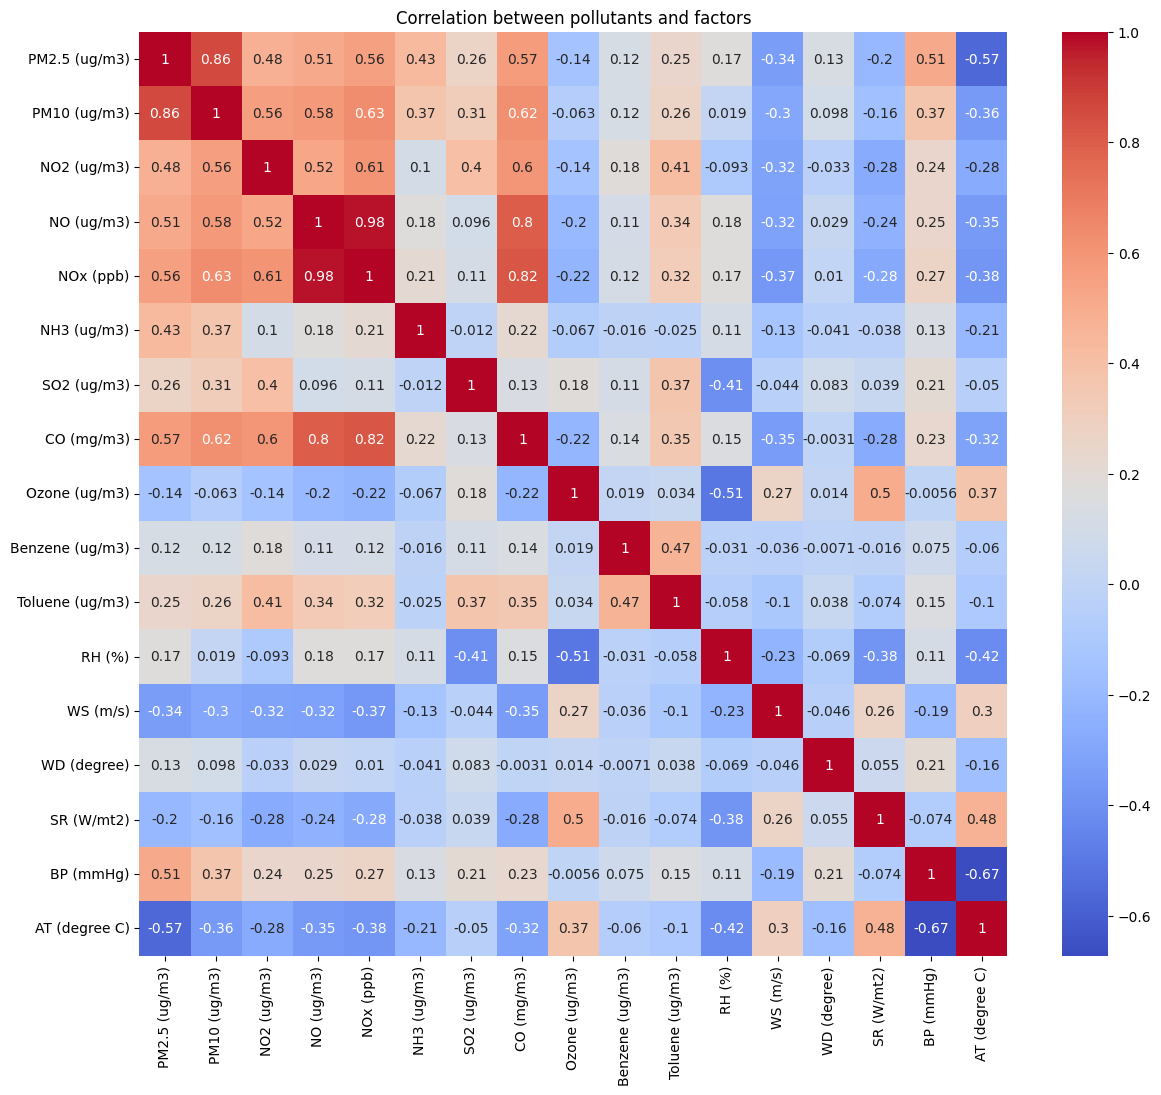

In [ ]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/DL024_FILLED_2023_AQI_NEW.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)','NOx (ppb)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

                 PM2.5 (ug/m3)  PM10 (ug/m3)  NO2 (ug/m3)  NO (ug/m3)  \
PM2.5 (ug/m3)         1.000000      0.756597     0.445339    0.540810   
PM10 (ug/m3)          0.756597      1.000000     0.553348    0.616711   
NO2 (ug/m3)           0.445339      0.553348     1.000000    0.525781   
NO (ug/m3)            0.540810      0.616711     0.525781    1.000000   
NH3 (ug/m3)           0.225488      0.163779     0.045391    0.158032   
SO2 (ug/m3)           0.168866      0.275464     0.322383    0.156726   
CO (mg/m3)            0.532259      0.658991     0.628271    0.780810   
Ozone (ug/m3)        -0.215938     -0.163549    -0.247751   -0.330884   
Benzene (ug/m3)       0.607155      0.624572     0.639086    0.633003   
Toluene (ug/m3)       0.404488      0.487472     0.576918    0.564549   
RH (%)                0.254874      0.021456     0.124010    0.288039   
WS (m/s)             -0.387803     -0.337158    -0.442043   -0.450637   
WD (degree)           0.086152      0.069827    -0.

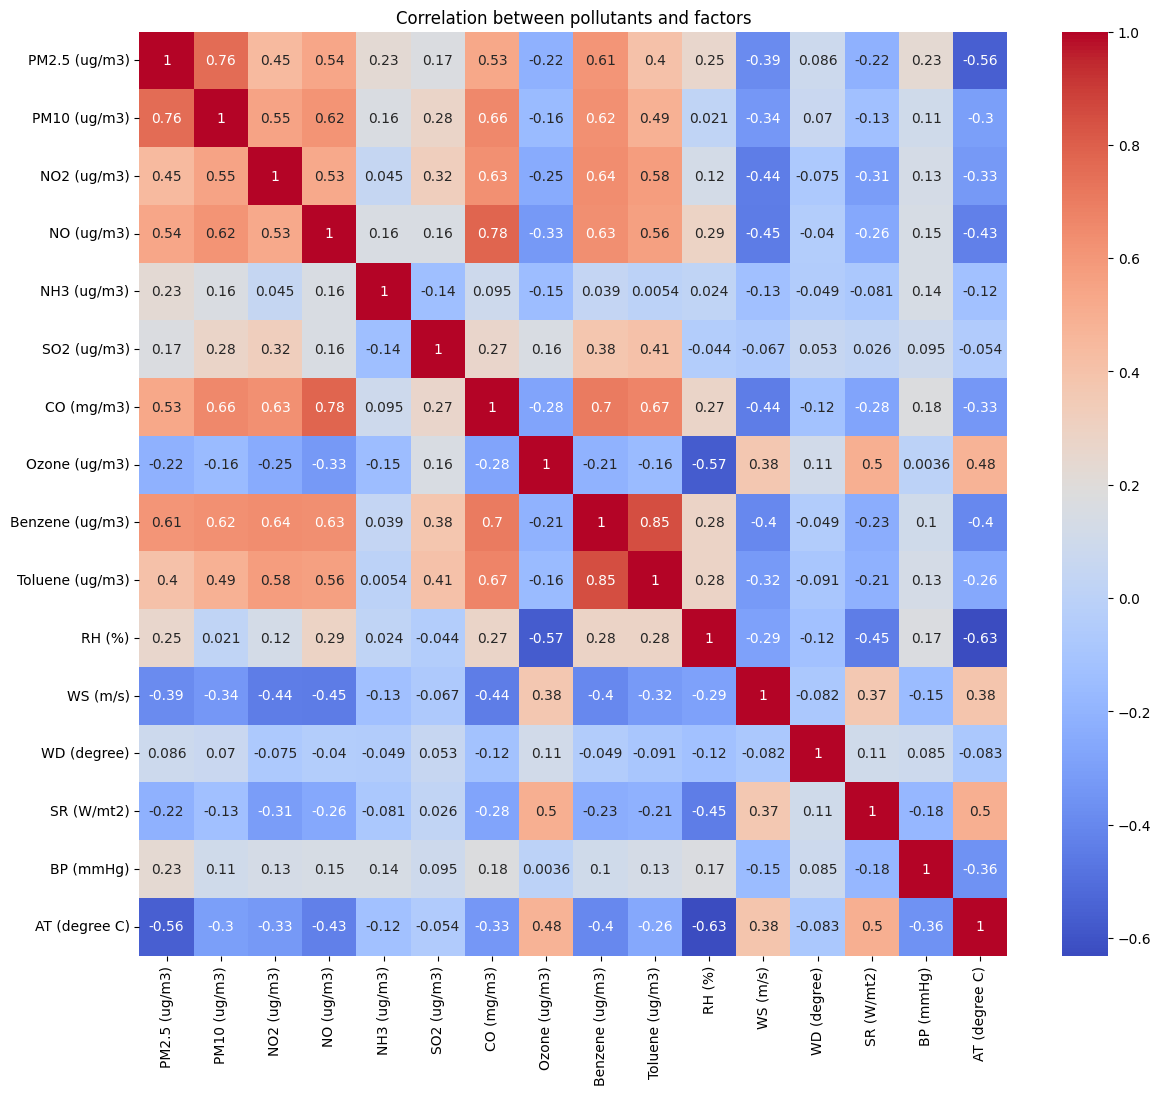

In [4]:
import pandas as pd    #south west and north west are actually different
#load the merged file
df=pd.read_excel("/DL030_FILLED_2023_AQI_NEW.xlsx")

#selct relevant numeric columns
column_to_compare=['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)','NO (ug/m3)', 'NH3 (ug/m3)','SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)','Benzene (ug/m3)','Toluene (ug/m3)','RH (%)','WS (m/s)','WD (degree)','SR (W/mt2)','BP (mmHg)','AT (degree C)']
data=df[column_to_compare]

data_interpolated = data.interpolate()

corr_matrix = data_interpolated.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12)) # Adjusting figure size for better clarity
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between pollutants and factors")
plt.show()

Date range of the loaded data:
Start Date: 2018-03-01 00:00:00
End Date: 2023-04-01 00:00:00

First 5 rows after interpolation:
   NO2 (ug/m3)
0        32.59
1        27.40
2        25.18
3        28.94
4        19.40

Description for NO2 (ug/m3):
count    44568.000000
mean        35.882113
std         26.373046
min          0.100000
25%         17.400000
50%         28.650000
75%         46.720000
max        417.730000
Name: NO2 (ug/m3), dtype: float64


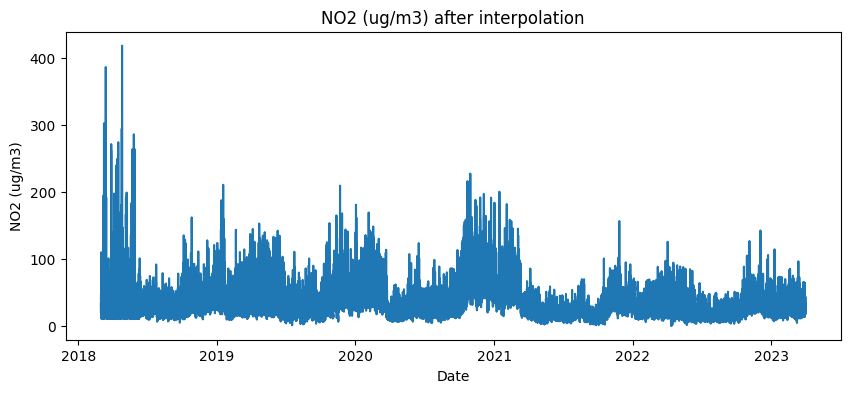

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#load the file - Make sure this path is correct for your data until 2023
file_path = "/DL030_FILLED_2023_AQI_NEW.xlsx" # Please ensure this file contains data up to 2023
df=pd.read_excel(file_path)

# Convert 'From Date' and 'To Date' to datetime objects
df['From Date'] = pd.to_datetime(df['From Date'], errors='coerce', format='mixed')
df['To Date'] = pd.to_datetime(df['To Date'], errors='coerce', format='mixed')

# Check the date range of the loaded data
print("Date range of the loaded data:")
print(f"Start Date: {df['From Date'].min()}")
print(f"End Date: {df['To Date'].max()}")

# Select the columns to interpolate
columns_to_interpolate = ['NO2 (ug/m3)']

# Perform linear interpolation on the selected columns and clip negative values to 0
for col in columns_to_interpolate:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear',order=1).clip(lower=0)
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")


# Save to new file
df.to_excel("DL030.xlsx", index=False)

# Display the first few values of the modified data for each interpolated column
print("\nFirst 5 rows after interpolation:")
print(df[columns_to_interpolate].head())

# Display descriptive statistics and plot for each interpolated column
for col in columns_to_interpolate:
    if col in df.columns:
        print(f"\nDescription for {col}:")
        print(df[col].describe())
        plt.figure(figsize=(10, 4))
        plt.plot(df['From Date'], df[col].values)
        plt.title(f'{col} after interpolation')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.show()

In [ ]:
!pip install pmdarima

### AQI BREAKPOINTS UNDER CPCB
The Central Pollution Control Board (CPCB) defines AQI breakpoints to convert pollutant concentrations into a standardized Air Quality Index. taking three regions into account For each pollutant such as PM2.5, PM10, NO₂, SO₂, CO, and O₃, specific concentration ranges are assigned corresponding AQI categories like Good, Satisfactory, Moderate, Poor, Very Poor, and Severe. Sub-indices for individual pollutants are calculated using CPCB breakpoint formulas, and the maximum sub-index is considered the final AQI value. These breakpoints help in uniformly assessing air quality and understanding the health impact associated with different pollution levels. The CPCB-based AQI system enables effective environmental monitoring, public awareness, and pollution control planning.



In [ ]:
from csv import excel
import pandas as pd
file_path="/DL030_FILLED_2023.xlsx"
df=pd.read_excel(file_path)
# CPCB AQI breakpoints for pollutants
breakpoints = {
    "PM2.5 (ug/m3)": [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 500, 401, 500)
    ],

    "PM10 (ug/m3)": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],

    "NO2 (ug/m3)": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 1000, 401, 500)
    ],

    "SO2 (ug/m3)": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 3600, 401, 500)
    ],

    "Ozone (ug/m3)": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ],

    "CO (mg/m3)": [
        (0, 1, 0, 50),
        (1.1, 2, 51, 100),
        (2.1, 10, 101, 200),
        (10.1, 17, 201, 300),
        (17.1, 34, 301, 400),
        (34.1, 50, 401, 500)
    ]
}

def compute_subindex(pollutant, concentration):
    if pollutant not in breakpoints or pd.isna(concentration):
        return None

    for BP_low, BP_high, I_low, I_high in breakpoints[pollutant]:
        if BP_low <= concentration <= BP_high:
            # Apply AQI formula
            aqi = ((I_high - I_low) / (BP_high - BP_low)) * (concentration - BP_low) + I_low
            return round(aqi)

    return None  # If not in any range


pollutants = ["PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO2 (ug/m3)", "SO2 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)"]

for p in pollutants:
    if p in df.columns:
        df[f"AQI_{p}"] = df[p].apply(lambda x: compute_subindex(p, x))
    else:
        df[f"AQI_{p}"] = None

# Final AQI = max of sub-indices
df["AQI_Final"] = df[[f"AQI_{p}" for p in pollutants]].max(axis=1)

# --- Start of new code to count and fill NaNs in AQI columns ---

aqi_columns = [f"AQI_{p}" for p in pollutants] + ["AQI_Final"]

print("\n--- NaN counts BEFORE interpolation for AQI columns ---")
print(df[aqi_columns].isnull().sum())

# Apply linear interpolation to all AQI columns
for col in aqi_columns:
    df[col] = df[col].interpolate(method='linear')

print("\n--- NaN counts AFTER interpolation for AQI columns ---")
print(df[aqi_columns].isnull().sum())

# --- End of new code ---

#save the file
df.to_excel("DL030_FILLED_AQI_2023.xlsx", index=False)
df.head()


In [ ]:
from google.colab import files

files.download("DL030_FILLED_AQI_2023.xlsx")


DOWNLOADING UPDATED CPCB AQI FILES


In [ ]:
import pandas as pd

# Load the new file
file_path_br005 = "/final_pollution_with_cpcb_aqi (dl030).xlsx"
df_br005 = pd.read_excel(file_path_br005)

# Display the first 5 rows to verify
print(f"Successfully loaded {file_path_br005}. First 5 rows:")
display(df_br005.head())

Successfully loaded /final_pollution_with_cpcb_aqi (dl030).xlsx. First 5 rows:


,From Date,year,month,day,hour,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,AQI_RF,AQI_XGB,AQI_LSTM,PM2.5_index,PM10_index,NO2_index,SO2_index,CO_index,O3_index,AQI_CPCB
0,2023-04-02 00:00:00,2023,4,2,0,89.620338,310.756561,35.147305,10.746246,1.058147,...,261.00,262.021759,NaN,198.703914,260.756561,43.934131,13.432808,48.721315,5.161453,260.756561
1,2023-04-02 01:00:00,2023,4,2,1,89.344490,279.777679,34.031788,10.777308,0.879659,...,230.00,230.551285,NaN,197.762225,229.777679,42.539735,13.471634,43.982950,5.161453,229.777679
2,2023-04-02 02:00:00,2023,4,2,2,92.964775,266.718781,30.683870,11.174823,0.912081,...,216.99,219.512405,NaN,207.707336,216.718781,38.354838,13.968529,45.604047,4.660219,216.718781
3,2023-04-02 03:00:00,2023,4,2,3,93.424706,242.089447,31.990612,10.542816,0.835435,...,209.80,205.012711,NaN,209.277443,194.743995,39.988265,13.178520,41.771773,3.740668,209.277443
4,2023-04-02 04:00:00,2023,4,2,4,87.284531,242.830231,33.149818,10.697456,0.875468,...,195.04,198.457275,NaN,190.729949,195.236194,41.437273,13.371820,43.773425,2.937582,195.236194


PLOTTING GRAPHS FOR EACH POLLUTANTS UNDER CPCB


In [ ]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import datetime as dt
import plotly.io as pio
import plotly.express as px

#reading the dataset and storing it as a dataframe
file_path_br005="/final_pollution_with_cpcb_aqi (br005).xlsx"
df_br005_loaded=pd.read_excel(file_path_br005) # Use separate variable for BR005

file_path_dl024 = "/final_pollution_with_cpcb_aqi(dl024).xlsx"
df_dl024_loaded = pd.read_excel(file_path_dl024) # Use separate variable for DL024

file_path_dl030 = "/final_pollution_with_cpcb_aqi (dl030).xlsx"
df_dl030_loaded = pd.read_excel(file_path_dl030) # Use separate variable for DL030

# Now, ensure 'df' for the initial 'regionStats' calculation is explicitly from DL030 data
# and copy it to avoid modifying the original df_dl030_loaded
df = df_dl030_loaded.copy()

#changing column names so that they don't have white-spaces, numbers, or any special-characters
df.rename(columns={
    'From Date': 'from_date',
    'To Date': 'to_date',
    'PM2.5 (ug/m3)': 'PM2.5',
    'PM10 (ug/m3)': 'PM10',
    'NO (ug/m3)': 'NO',
    'NO2 (ug/m3)': 'NO2',
    'NH3 (ug/m3)': 'NH3',
    'SO2 (ug/m3)': 'SO2',
    'CO (mg/m3)': 'CO',
    'Ozone (ug/m3)': 'Ozone'
}, inplace=True)

# Convert 'from_date' to datetime objects
df['from_date'] = pd.to_datetime(df['from_date'], errors='coerce')
# --- FIX START --- Remove rows with NaT values in 'from_date'
df.dropna(subset=['from_date'], inplace=True)
# --- FIX END ---

# List of pollutant columns to interpolate
pollutant_columns_to_interpolate = ['PM2.5','PM10','NO','NO2','NH3','SO2','CO','Ozone']

# Apply linear interpolation to pollutant columns
for col in pollutant_columns_to_interpolate:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear')

#extracting the 'Month' from the Date
df['Month'] = df['from_date'].dt.month

#creating a new column 'MonthNumber' by converting the 'Month' column values to integers
df['MonthNumber'] = df['Month'].apply(lambda x: int(x))

#creating a new column 'MonthName' by converting the 'MonthNumber' column values to the monthNames
df['MonthName'] = df['MonthNumber'].apply(lambda x: calendar.month_abbr[x])
#extracting the 'Year' from the date
df['Year'] = df['from_date'].dt.year
#grouping by 'MonthName' and finding mean values for the numerical columns
regionStats = df.groupby(['Year','MonthName'])[['PM2.5','PM10','NO2','SO2','CO','Ozone']].mean().reset_index()


regionStats = regionStats.sort_values(['Year', 'MonthName'])

# --- Function to process dataframes ---
def process_dataframe(data_frame, pollutant_cols):
    data_frame.rename(columns={
        'From Date': 'from_date',
        'To Date': 'to_date'
    }, inplace=True)
    data_frame['from_date'] = pd.to_datetime(data_frame['from_date'], errors='coerce')
    # --- FIX START --- Remove rows with NaT values in 'from_date' within the function
    data_frame.dropna(subset=['from_date'], inplace=True)
    # --- FIX END ---
    data_frame['Month'] = data_frame['from_date'].dt.month
    data_frame['MonthNumber'] = data_frame['Month'].apply(lambda x: int(x))
    data_frame['MonthName'] = data_frame['MonthNumber'].apply(lambda x: calendar.month_abbr[x])
    data_frame['Year'] = data_frame['from_date'].dt.year

    # Filter out columns that do not exist in the dataframe
    valid_pollutant_cols = [col for col in pollutant_cols if col in data_frame.columns]

    region_stats = data_frame.groupby(['Year','MonthName'])[valid_pollutant_cols].mean().reset_index()
    region_stats = region_stats.sort_values(['Year', 'MonthName'])
    return region_stats

pollutant_columns = [
    'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)'
]

# --- Process df_br005 ---
regionStats_br005 = process_dataframe(df_br005_loaded, pollutant_columns)

# --- Process df_dl024 ---
regionStats_dl024 = process_dataframe(df_dl024_loaded, pollutant_columns)

# --- Process df_dl030 ---
regionStats_dl030 = process_dataframe(df_dl030_loaded, pollutant_columns)

display(df.head())

,from_date,year,month,day,hour,PM2.5,PM10,NO2,SO2,CO,...,NO2_index,SO2_index,CO_index,O3_index,AQI_CPCB,Ensemble_AQI,Month,MonthNumber,MonthName,Year
0,2023-04-02 00:00:00,2023,4,2,0,89.620338,310.756561,35.147305,10.746246,1.058147,...,43.934131,13.432808,48.721315,5.161453,260.756561,197.454178,4,4,Apr,2023
1,2023-04-02 01:00:00,2023,4,2,1,89.344490,279.777679,34.031788,10.777308,0.879659,...,42.539735,13.471634,43.982950,5.161453,229.777679,176.964020,4,4,Apr,2023
2,2023-04-02 02:00:00,2023,4,2,2,92.964775,266.718781,30.683870,11.174823,0.912081,...,38.354838,13.968529,45.604047,4.660219,216.718781,169.281060,4,4,Apr,2023
3,2023-04-02 03:00:00,2023,4,2,3,93.424706,242.089447,31.990612,10.542816,0.835435,...,39.988265,13.178520,41.771773,3.740668,209.277443,162.384495,4,4,Apr,2023
4,2023-04-02 04:00:00,2023,4,2,4,87.284531,242.830231,33.149818,10.697456,0.875468,...,41.437273,13.371820,43.773425,2.937582,195.236194,155.612683,4,4,Apr,2023


In [ ]:
yearly_avg = regionStats_long.groupby(
    ['Year', 'Pollutant'], as_index=False
)['Concentration'].mean()

plt.figure(figsize=(15, 7))

sns.barplot(
    data=yearly_avg,
    x='Year',
    y='Concentration',
    hue='Pollutant'
)

plt.title('Year-wise Average Pollutant Concentration')
plt.xlabel('Year')
plt.ylabel('Average Concentration')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


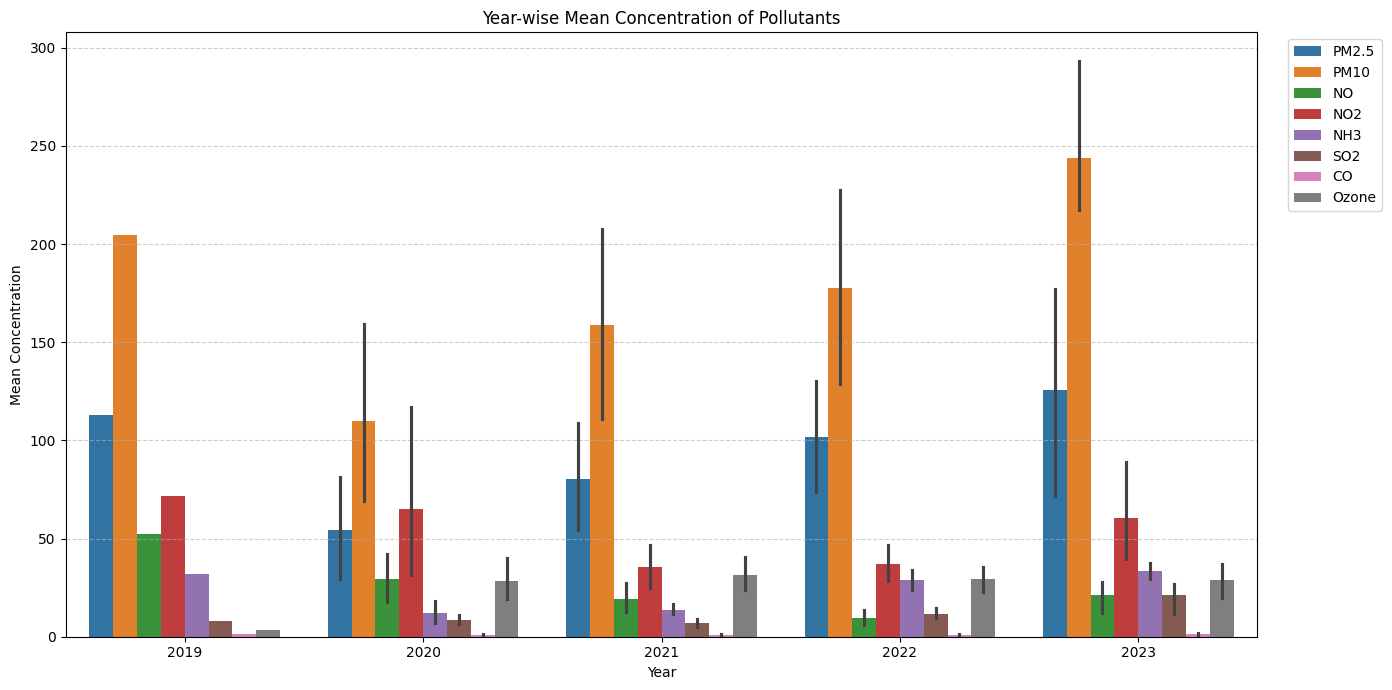

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the regionStats DataFrame to a long format
regionStats_long = regionStats.melt(
    id_vars=['Year'],
    value_vars=['PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'SO2', 'CO', 'Ozone'],
    var_name='Pollutant',
    value_name='MeanConcentration'
)
plt.figure(figsize=(14, 7))

sns.barplot(
    data=regionStats_long,
    x='Year',
    y='MeanConcentration',
    hue='Pollutant'
)

plt.title('Year-wise Mean Concentration of Pollutants')
plt.xlabel('Year')
plt.ylabel('Mean Concentration')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Standardize column names for regionStats_br005 to match regionStats
regionStats_br005_renamed = regionStats_br005.rename(columns={
    'PM2.5 (ug/m3)': 'PM2.5',
    'PM10 (ug/m3)': 'PM10',
    'NO2 (ug/m3)': 'NO2',
    'SO2 (ug/m3)': 'SO2',
    'CO (mg/m3)': 'CO',
    'Ozone (ug/m3)': 'Ozone',
})

# Add a 'Dataset' column to distinguish the data sources
regionStats_br005['Dataset'] = 'BR005_CPCB_AQI_File'
regionStats_dl024['Dataset'] = 'DL030_CPCB_AQI_File'
regionStats_dl030['Dataset'] = 'DL024_CPCB_AQI_File'

# Concatenate the two dataframes
combined_region_stats = pd.concat([regionStats_br005, regionStats_dl024,regionStats_dl030], ignore_index=True)

# Define pollutants common to both datasets after renaming
# Note: 'NO', 'NH3' were only in regionStats, and 'NOx' was not created in regionStats_br005
common_pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

for pollutant in common_pollutants:
    fig = px.bar(combined_region_stats,
                 x='MonthName',
                 y=pollutant_columns,
                 color='Year',
                 barmode='group',
                 facet_col='Dataset', # Use facet_col to compare the two datasets side-by-side
                 title=f'Average {pollutant} Concentration Month-wise by Dataset',
                 labels={'MonthName': 'Month', pollutant: f'Average {pollutant} Concentration'},
                 category_orders={'MonthName': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']}
                 )
    fig.update_layout(height=400, showlegend=True)
    fig.show()


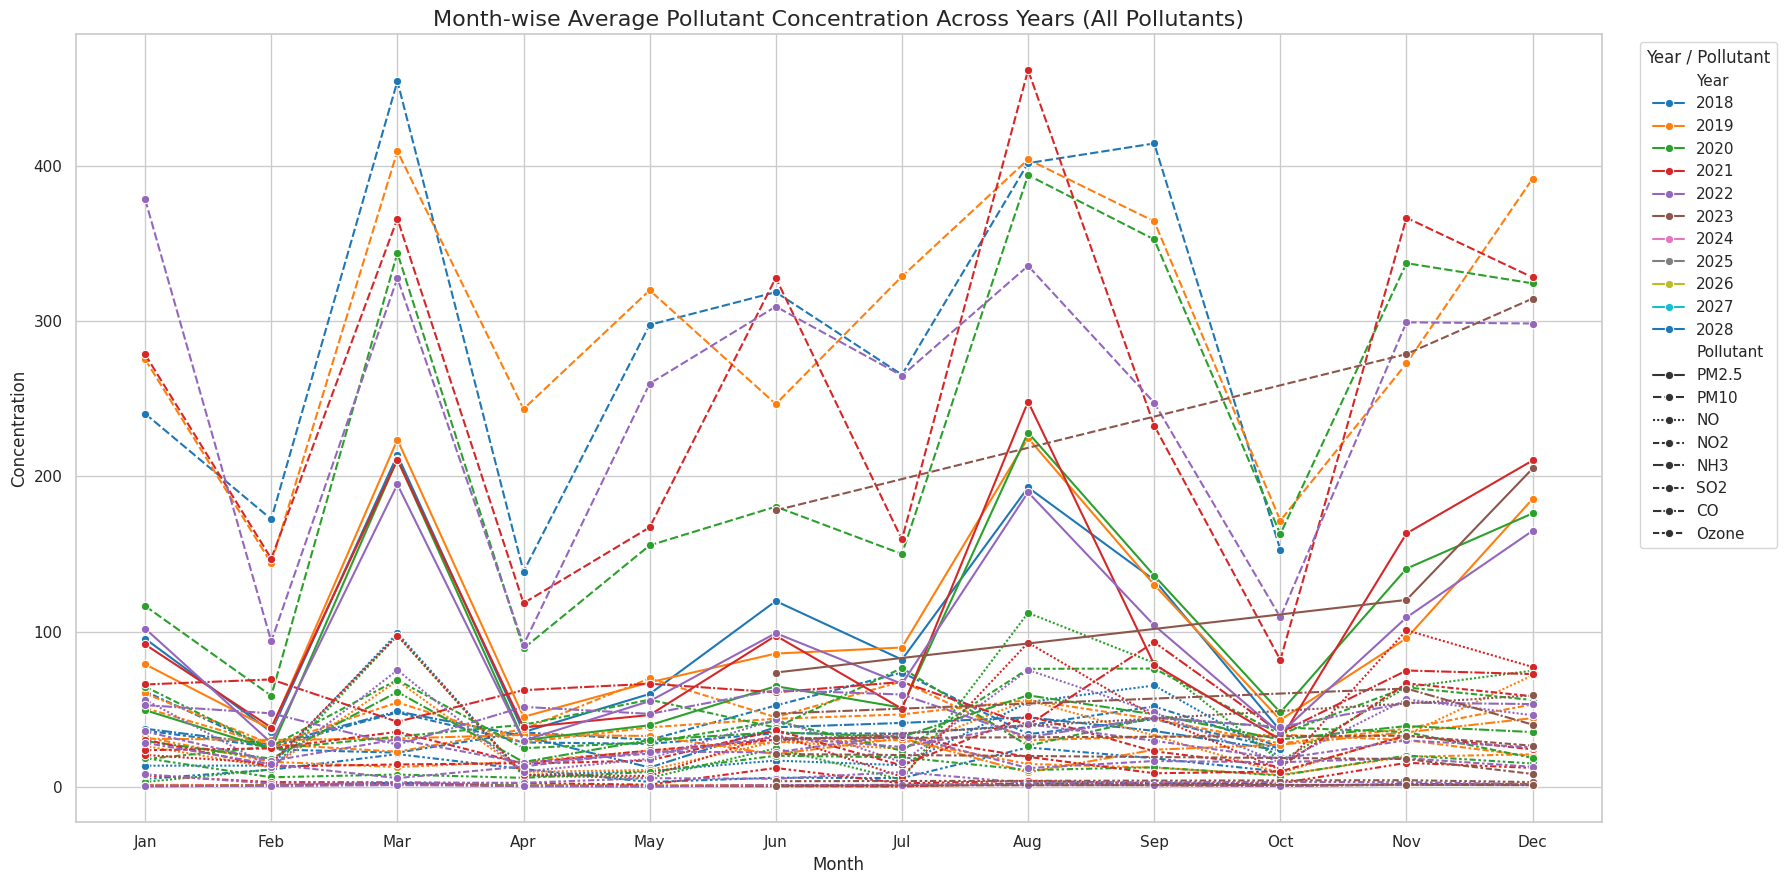

First 5 rows of regionStats_br005_long_all:


,Year,MonthName,Metric,Value
0,2023,Apr,PM2.5 (ug/m3),83.442983
1,2023,Aug,PM2.5 (ug/m3),16.042579
2,2023,Dec,PM2.5 (ug/m3),181.632871
3,2023,Jul,PM2.5 (ug/m3),17.959242
4,2023,Jun,PM2.5 (ug/m3),37.298728


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Melt the regionStats DataFrame to a long format
regionStats_long_all = regionStats.melt(
    id_vars=['Year', 'MonthName'],
    value_vars=['PM2.5', 'PM10', 'NO', 'NO2',  'NH3', 'SO2', 'CO', 'Ozone'],
    var_name='Pollutant',
    value_name='Concentration'
)

# Melt the regionStats_br005 DataFrame to a long format
# Assuming regionStats_br005 is already computed from df_br005 with relevant columns
regionStats_br005_long_all = regionStats_br005.melt(
    id_vars=['Year', 'MonthName'],
    value_vars=[
        'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)'
    ],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(18, 9)) # Adjust figure size for better readability

# Combine unique years from both dataframes for consistent hue ordering
all_years = np.unique(np.concatenate((regionStats_long_all['Year'].unique(), regionStats_br005_long_all['Year'].unique())))

sns.lineplot(
    data=regionStats_long_all,
    x='MonthName',
    y='Concentration',
    hue='Year',
    style='Pollutant', # Use 'style' to differentiate pollutants (now includes shape and dash)
    marker='o',
    palette='tab10',
    hue_order=sorted(all_years),
    errorbar=None # Remove error bars for cleaner look if not needed
)

plt.xticks(ticks=range(12), labels=month_order)
plt.title('Month-wise Average Pollutant Concentration Across Years (All Pollutants)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Concentration', fontsize=12)
plt.legend(title='Year / Pollutant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("First 5 rows of regionStats_br005_long_all:")
display(regionStats_br005_long_all.head())

In [ ]:
from google.colab import files
files.download("future_pollution_with_aqi_xg_predictions.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**PREDICTION OF POLLUTANTS BY XGBOOST AND APPLYING XGBOOST, RFR, LSTM FOR AQI PREDICTION UNDER CPCB RANGES FOR POLLUTANTS AND ALSO EVALUATING MODEL METRIC AND POLLUTANT METRIC**

XGBoost was initially used to predict future pollutant concentrations because of its strong capability to model complex nonlinear relationships and handle large environmental datasets efficiently. The predicted pollutant values were then converted into CPCB-based AQI sub-indices using standard breakpoint formulas to ensure that the AQI remained within officially accepted pollution categories. For AQI forecasting, three models—XGBoost, Random Forest Regressor (RFR), and LSTM—were applied, where Random Forest and XGBoost captured nonlinear pollutant interactions while LSTM modeled temporal and sequential dependencies in air quality data. The predictions from these models were further analyzed using evaluation metrics such as MSE, RMSE, and R² to measure prediction accuracy and reliability. In addition, pollutant-wise metrics were evaluated to understand the predictive performance of each pollutant individually and identify the dominant contributors influencing AQI levels.


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel("/BR005_FILLED_AQI _2023.xlsx")

df['From Date'] = pd.to_datetime(df['From Date'])

# ==============================
# 2. CREATE TIME FEATURES
# ==============================
df['year'] = df['From Date'].dt.year
df['month'] = df['From Date'].dt.month
df['day'] = df['From Date'].dt.day
df['hour'] = df['From Date'].dt.hour

# ==============================
# 3. DEFINE POLLUTANTS
# ==============================
pollutants = [
    "PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO2 (ug/m3)",
    "SO2 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)"
]

features = ['year', 'month', 'day', 'hour']

# ==============================
# 4. TRAIN XGBOOST MODELS
# ==============================
models = {}

for col in pollutants:
    model = XGBRegressor(n_estimators=200, max_depth=5)
    model.fit(df[features], df[col])
    models[col] = model

# ==============================
# 5. CREATE FUTURE TIME RANGE
# ==============================
future_dates = pd.date_range(
    start="2023-04-02",
    end="2028-12-31",
    freq="H"
)

future_df = pd.DataFrame()
future_df['From Date'] = future_dates

# Create features
future_df['year'] = future_df['From Date'].dt.year
future_df['month'] = future_df['From Date'].dt.month
future_df['day'] = future_df['From Date'].dt.day
future_df['hour'] = future_df['From Date'].dt.hour

# ==============================
# 6. PREDICT POLLUTANTS
# ==============================
for col in pollutants:
    future_df[col] = models[col].predict(future_df[features])

# Remove negative values
for col in pollutants:
    future_df[col] = future_df[col].clip(lower=0)
    # ==============================
# 7. RANDOM FOREST AQI
# ==============================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(df[pollutants], df['AQI_Final'])

future_df['AQI_RF'] = rf_model.predict(future_df[pollutants])
future_df['AQI_RF'] = future_df['AQI_RF'].clip(lower=10)

# Evaluate RF model on training data (original df for KPI calculation)
rf_preds_train = rf_model.predict(df[pollutants])
print("\nRandom Forest AQI Metrics on training data:")
print(f"  MAE: {mean_absolute_error(df['AQI_Final'], rf_preds_train):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(df['AQI_Final'], rf_preds_train)):.2f}")
print(f"  R-squared: {r2_score(df['AQI_Final'], rf_preds_train):.2f}")

# ==============================
# 8. XGBOOST AQI
# ==============================
xgb_aqi_model = XGBRegressor(n_estimators=100, random_state=42) # Different model for AQI_Final
xgb_aqi_model.fit(df[pollutants], df['AQI_Final'])

future_df['AQI_XGB'] = xgb_aqi_model.predict(future_df[pollutants])
future_df['AQI_XGB'] = future_df['AQI_XGB'].clip(lower=10)

# Evaluate XGBoost AQI model on training data
xgb_aqi_preds_train = xgb_aqi_model.predict(df[pollutants])
print("\nXGBoost AQI Metrics on training data:")
print(f"  MAE: {mean_absolute_error(df['AQI_Final'], xgb_aqi_preds_train):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(df['AQI_Final'], xgb_aqi_preds_train)):.2f}")
print(f"  R-squared: {r2_score(df['AQI_Final'], xgb_aqi_preds_train):.2f}")

# ==============================
# 9. LSTM AQI
# ==============================
clean_data = df[pollutants + ['AQI_Final']].dropna()

input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

scaled_X = input_scaler.fit_transform(clean_data[pollutants])
scaled_y = output_scaler.fit_transform(clean_data[['AQI_Final']])

combined = np.hstack((scaled_X, scaled_y))

def create_seq(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, :-1])
        y.append(data[i+window, -1])
    return np.array(X), np.array(y)

X_seq, y_seq = create_seq(combined, 24)

split = int(0.8 * len(X_seq))
X_train, y_train = X_seq[:split], y_seq[:split]

model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

scaled_future = input_scaler.transform(future_df[pollutants])

future_seq = []
for i in range(len(scaled_future) - 24):
    future_seq.append(scaled_future[i:i+24])

future_seq = np.array(future_seq)

lstm_pred = model_lstm.predict(future_seq)
lstm_pred = output_scaler.inverse_transform(lstm_pred)

future_df['AQI_LSTM'] = np.nan
future_df.loc[future_df.index[-len(lstm_pred):], 'AQI_LSTM'] = lstm_pred.flatten()
future_df['AQI_LSTM'] = future_df['AQI_LSTM'].clip(lower=10)

# Evaluate LSTM model on training data (for KPI calculation)
# Need to create sequences for the original clean_data for evaluation
clean_data_X_scaled = input_scaler.transform(clean_data[pollutants])
clean_data_y_scaled = output_scaler.transform(clean_data[['AQI_Final']])
clean_data_combined = np.hstack((clean_data_X_scaled, clean_data_y_scaled))

X_clean_seq, y_clean_seq = create_seq(clean_data_combined, 24)

if len(X_clean_seq) > 0:
    lstm_preds_train_scaled = model_lstm.predict(X_clean_seq)
    lstm_preds_train = output_scaler.inverse_transform(lstm_preds_train_scaled).flatten()
    y_clean_actual = output_scaler.inverse_transform(y_clean_seq.reshape(-1, 1)).flatten()

    print("\nLSTM AQI Metrics on training data:")
    print(f"  MAE: {mean_absolute_error(y_clean_actual, lstm_preds_train):.2f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_clean_actual, lstm_preds_train)):.2f}")
    print(f"  R-squared: {r2_score(y_clean_actual, lstm_preds_train):.2f}")
else:
    print("\nNot enough data to create LSTM sequences for training data evaluation.")

# ==============================
# 10. CPCB SUB-INDEX FUNCTION
# ==============================
def sub_index(c, I_lo, I_hi, BP_lo, BP_hi):
    return ((I_hi - I_lo) / (BP_hi - BP_lo)) * (c - BP_lo) + I_lo

# ==============================
# 11. POLLUTANT BREAKPOINT FUNCTIONS
# ==============================

def pm25_index(c):
    if c <= 30: return sub_index(c, 0, 50, 0, 30)
    elif c <= 60: return sub_index(c, 51, 100, 31, 60)
    elif c <= 90: return sub_index(c, 101, 200, 61, 90)
    elif c <= 120: return sub_index(c, 201, 300, 91, 120)
    elif c <= 250: return sub_index(c, 301, 400, 121, 250)
    else: return sub_index(c, 401, 500, 251, 500)

def pm10_index(c):
    if c <= 50: return sub_index(c, 0, 50, 0, 50)
    elif c <= 100: return sub_index(c, 51, 100, 51, 100)
    elif c <= 250: return sub_index(c, 101, 200, 101, 250)
    elif c <= 350: return sub_index(c, 201, 300, 251, 350)
    elif c <= 430: return sub_index(c, 301, 400, 351, 430)
    else: return sub_index(c, 401, 500, 431, 600)

def no2_index(c):
    if c <= 40: return sub_index(c, 0, 50, 0, 40)
    elif c <= 80: return sub_index(c, 51, 100, 41, 80)
    elif c <= 180: return sub_index(c, 101, 200, 81, 180)
    elif c <= 280: return sub_index(c, 201, 300, 181, 280)
    elif c <= 400: return sub_index(c, 301, 400, 281, 400)
    else: return sub_index(c, 401, 500, 401, 500)

def so2_index(c):
    if c <= 40: return sub_index(c, 0, 50, 0, 40)
    elif c <= 80: return sub_index(c, 51, 100, 41, 80)
    elif c <= 380: return sub_index(c, 101, 200, 81, 380)
    elif c <= 800: return sub_index(c, 201, 300, 381, 800)
    elif c <= 1600: return sub_index(c, 301, 400, 801, 1600)
    else: return sub_index(c, 401, 500, 1601, 2000)

def co_index(c):
    if c <= 1: return sub_index(c, 0, 50, 0, 1)
    elif c <= 2: return sub_index(c, 51, 100, 1.1, 2)
    elif c <= 10: return sub_index(c, 101, 200, 2.1, 10)
    elif c <= 17: return sub_index(c, 201, 300, 10.1, 17)
    elif c <= 34: return sub_index(c, 301, 400, 17.1, 34)
    else: return sub_index(c, 401, 500, 34.1, 50)

def o3_index(c):
    if c <= 50: return sub_index(c, 0, 50, 0, 50)
    elif c <= 100: return sub_index(c, 51, 100, 51, 100)
    elif c <= 168: return sub_index(c, 101, 200, 101, 168)
    elif c <= 208: return sub_index(c, 201, 300, 169, 208)
    elif c <= 748: return sub_index(c, 301, 400, 209, 748)
    else: return sub_index(c, 401, 500, 749, 1000)

# ==============================
# 12. CALCULATE SUB-INDICES
# ==============================
future_df['PM2.5_index'] = future_df["PM2.5 (ug/m3)"].apply(pm25_index)
future_df['PM10_index'] = future_df["PM10 (ug/m3)"].apply(pm10_index)
future_df['NO2_index'] = future_df["NO2 (ug/m3)"].apply(no2_index)
future_df['SO2_index'] = future_df["SO2 (ug/m3)"].apply(so2_index)
future_df['CO_index'] = future_df["CO (mg/m3)"].apply(co_index)
future_df['O3_index'] = future_df["Ozone (ug/m3)"].apply(o3_index)

# ==============================
# 13. FINAL AQI (CPCB METHOD)
# ==============================
future_df['AQI_CPCB'] = future_df[
    ['PM2.5_index', 'PM10_index', 'NO2_index',
     'SO2_index', 'CO_index', 'O3_index']
].max(axis=1)

# Evaluate XGBoost models for each pollutant on training data (original df for KPI calculation)
print("\nXGBoost Pollutant Prediction Metrics on training data:")
for col in pollutants:
    xgb_preds_train = models[col].predict(df[features])
    print(f"  {col}:")
    print(f"    MAE: {mean_absolute_error(df[col], xgb_preds_train):.2f}")
    print(f"    RMSE: {np.sqrt(mean_squared_error(df[col], xgb_preds_train)):.2f}")
    print(f"    R-squared: {r2_score(df[col], xgb_preds_train):.2f}")

# ==============================
# 14. SAVE OUTPUT
# ==============================
future_df.to_excel("final_pollution_with_cpcb_aqi.xlsx", index=False)

print("✅ DONE: Pollutants + CPCB AQI saved successfully!")

/tmp/ipykernel_13893/2705485412.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(



Random Forest AQI Metrics on training data:
  MAE: 0.22
  RMSE: 1.87
  R-squared: 1.00

XGBoost AQI Metrics on training data:
  MAE: 1.69
  RMSE: 3.38
  R-squared: 1.00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
895/895 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

LSTM AQI Metrics on training data:
  MAE: 17.98
  RMSE: 29.29
  R-squared: 0.94

XGBoost Pollutant Prediction Metrics on training data:
  PM2.5 (ug/m3):
    MAE: 14.03
    RMSE: 22.31
    R-squared: 0.89
  PM10 (ug/m3):
    MAE: 26.12
    RMSE: 41.20
    R-squared: 0.87
  NO2 (ug/m3):
    MAE: 8.04
    RMSE: 12.61
    R-squared: 0.97
  SO2 (ug/m3):
    MAE: 2.22
    RMSE: 3.89
    R-squared: 0.79
  CO (mg/m3):
    MAE: 0.22
    RMSE: 0.34
    R-squared: 0.84
  Ozone (ug/m3):
    MAE: 7.84
    RMSE: 11.36
    R-squared: 0.84
✅ DONE: Pollutants + CPCB AQI saved successfully!


COMPARISON GRAPH BETWEEN ACTUAL VS PREDICTED AQI

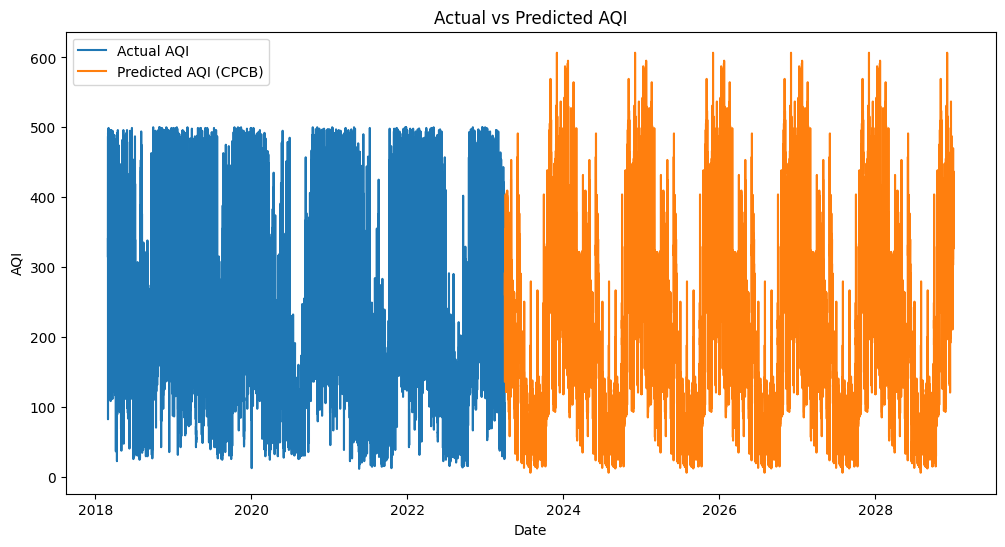

In [ ]:
#graph
import pandas as pd
import matplotlib.pyplot as plt

# Original data (till 3rd April 2023)
original_data = pd.read_excel("/DL030_FILLED_2023_AQI_NEW.xlsx")

# Predicted data (4th April 2023 onwards)
predicted_data = pd.read_excel("/final_pollution_with_cpcb_aqi.xlsx")

# standardize the date time
original_data['Date'] = pd.to_datetime(original_data['From Date'])
predicted_data['Date'] = pd.to_datetime(predicted_data['From Date'])

#compare only required original aqi with multiple predicted aqi
original_data = original_data[['Date', 'AQI_Final']]
predicted_data = predicted_data[['Date','AQI_CPCB','AQI_RF','AQI_LSTM']]

#rename
original_data.rename(columns={'AQI_Final': 'Actual_AQI'}, inplace=True)
predicted_data.rename(columns={'AQI_CPCB':'Predicted_AQI'}, inplace=True)

#combined columns
combined_data = pd.concat([original_data, predicted_data], ignore_index=True)

# Sort by date
combined_data = combined_data.sort_values(by='Date')
#graphs for comparison between aqi
plt.figure(figsize=(12,6))

plt.plot(combined_data['Date'], combined_data['Actual_AQI'], label='Actual AQI')
plt.plot(combined_data['Date'], combined_data['Predicted_AQI'], label='Predicted AQI (CPCB)')

plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()

plt.show()

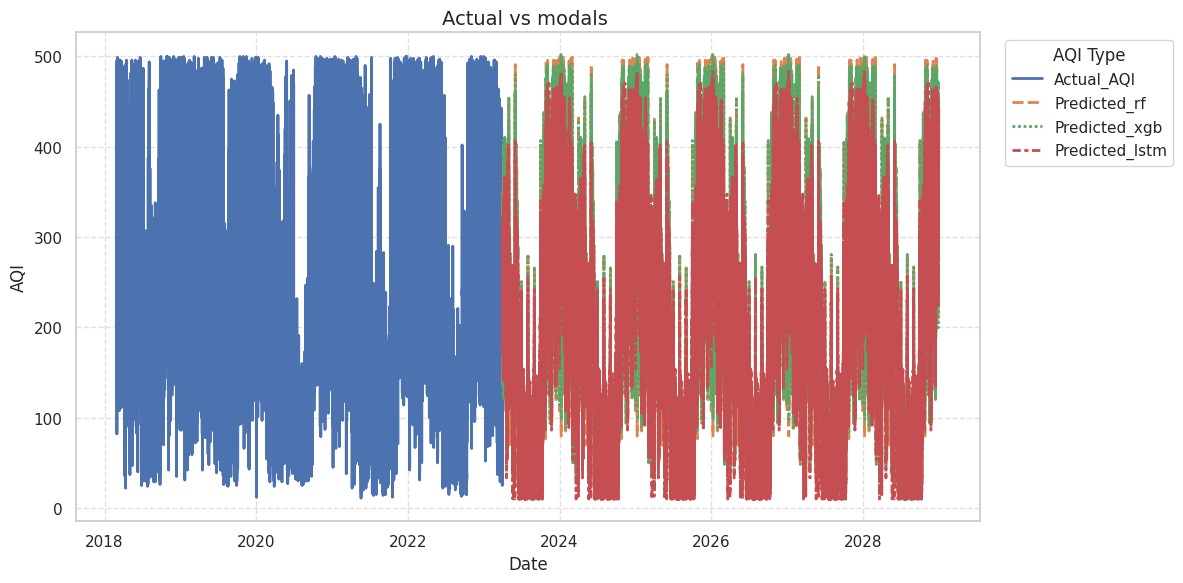

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Original data (till 3rd April 2023)
original_data = pd.read_excel("/DL030_FILLED_2023_AQI_NEW.xlsx")

# Predicted data (4th April 2023 onwards)
predicted_data = pd.read_excel("/final_pollution_with_cpcb_aqi.xlsx")

# standardize the date time
original_data['Date'] = pd.to_datetime(original_data['From Date'])
predicted_data['Date'] = pd.to_datetime(predicted_data['From Date'])

#compare only required original aqi with multiple predicted aqi
original_data = original_data[['Date', 'AQI_Final']]
predicted_data = predicted_data[['Date','AQI_XGB','AQI_RF','AQI_LSTM']]

#rename
original_data.rename(columns={'AQI_Final': 'Actual_AQI'}, inplace=True)
predicted_data.rename(columns={'AQI_RF':'Predicted_rf','AQI_XGB':'Predicted_xgb','AQI_LSTM': 'Predicted_lstm'}, inplace=True)

#combined columns
combined_data = pd.concat([original_data, predicted_data], ignore_index=True)

# Sort by date
combined_data = combined_data.sort_values(by='Date')

# Define rolling window size
window_size = 7


# Melt the DataFrame for easier plotting with different line styles
combined_melted = combined_data.melt(
    id_vars=['Date'],
    value_vars=['Actual_AQI', 'Predicted_rf', 'Predicted_xgb', 'Predicted_lstm'],
    var_name='AQI_Type',
    value_name='AQI_Value'
)

# Set the style for the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=combined_melted,
    x='Date',
    y='AQI_Value',
    hue='AQI_Type',
    style='AQI_Type', # Use 'style' to differentiate line patterns for different AQI types
    linewidth=2, # Increase line width for better visibility
    palette='deep' # Use a distinct color palette
)

plt.title(f'Actual vs modals ', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.legend(title='AQI Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download("/future_pollution_with_aqi_trial(dl030).xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("final_pollution_with_cpcb_aqi.xlsx")

FileNotFoundError: Cannot find file: final_pollution_with_cpcb_aqi.xlsx

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45230 entries, 0 to 45229
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   From Date          45230 non-null  datetime64[ns]
 1   To Date            45230 non-null  datetime64[ns]
 2   PM2.5 (ug/m3)      45230 non-null  float64       
 3   PM10 (ug/m3)       45230 non-null  float64       
 4   NO (ug/m3)         45230 non-null  float64       
 5   NO2 (ug/m3)        45230 non-null  float64       
 6   NOx (ppb)          45230 non-null  float64       
 7   NH3 (ug/m3)        45230 non-null  float64       
 8   SO2 (ug/m3)        45230 non-null  float64       
 9   CO (mg/m3)         45230 non-null  float64       
 10  Ozone (ug/m3)      45230 non-null  float64       
 11  Benzene (ug/m3)    45230 non-null  float64       
 12  Toluene (ug/m3)    45230 non-null  float64       
 13  RH (%)             45230 non-null  float64       
 14  WS (m/

In [ ]:
from google.colab import files
files.download("final_aqi_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ADF TEST**

The Augmented Dickey–Fuller (ADF) test is a statistical test used to determine whether a time-series dataset is stationary or non-stationary. In AQI forecasting, stationarity is important because models such as ARIMA require the data or residuals to have constant mean and variance over time. The ADF test checks for the presence of a unit root in the series; if the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected, indicating that the data is stationary. In this project, the ADF test was applied to the residuals before ARIMA modeling to verify whether the residual series was suitable for time-series forecasting. This helped ensure the reliability and stability of the residual-based hybrid AQI prediction framework.


In [ ]:
# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("/final_aqi_predictions ().csv")


# ADF Test with critical values
from statsmodels.tsa.stattools import adfuller

# Run ADF Test
adf_result = adfuller(df['Residuals_Actual'])

# Extract values
adf_stat = adf_result[0]
p_value = adf_result[1]
crit_vals = adf_result[4]

# Print results
print("ADF Statistic:", adf_stat)
print("p-value:", p_value)

print("\nCritical Values:")
print("1% level:", crit_vals['1%'])
print("5% level:", crit_vals['5%'])
print("10% level:", crit_vals['10%'])

ADF Statistic: -17.43753939148322
p-value: 4.729273915148787e-30

Critical Values:
1% level: -3.4307175533102483
5% level: -2.8617024445359016
10% level: -2.566856464980454


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.1 MB/s eta 0:00:00


In [ ]:
pip install openpyxl


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.7 MB/s eta 0:00:00


PREDICTION OF RESIDUALS AND ARIMA FITTED RESIDUALS

The data is split into training and testing sets based on time, using 60% for training and 40% for testing. It then trains three individual models: a Random Forest Regressor, an XGBoost Regressor, and an LSTM (Long Short-Term Memory) neural network. For the LSTM model, data is scaled and reshaped appropriately for time-series input. Next, it creates an ensemble prediction by averaging the outputs of the Random Forest, XGBoost, and LSTM models. The residuals (differences between actual and ensemble-predicted AQI) are then calculated. An Auto ARIMA model is applied to these residuals to capture any remaining time-series patterns. The ARIMA model predicts these residuals, which are then added to the ensemble predictions to form the 'Final Hybrid AQI' prediction. Finally, the code evaluates the performance of the full ensemble, an XGBoost+LSTM ensemble, and the final hybrid model using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared, and saves the results to a CSV file.

In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from statsmodels.tsa.arima.model import ARIMA

!pip install pmdarima
from pmdarima import auto_arima

# ================================
# 2. LOAD DATA
# ================================
# df should contain pollutants + AQI column
# Example columns: ['PM2.5','PM10','NO2','SO2','CO','O3','AQI']

df = pd.read_excel("/BR005_FILLED_AQI _2023.xlsx")

# Ensure 'From Date' is datetime type
df['From Date'] = pd.to_datetime(df['From Date'])

# ================================
# 3. FEATURES & TARGET
# ================================
FEATURE_COLS = [
    'AQI_PM2.5 (ug/m3)',
    'AQI_PM10 (ug/m3)',
    'AQI_NO2 (ug/m3)',
    'AQI_SO2 (ug/m3)',
    'AQI_CO (mg/m3)',
    'AQI_Ozone (ug/m3)'
]
X = df[FEATURE_COLS]
y = df['AQI_Final']

# ================================
# 4. TRAIN-TEST SPLIT (TIME SERIES)
# ================================
split = int(len(df)*0.6)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Get 'From Date' for the test set
test_dates = df['From Date'][split:].values

# ================================
# 5. RANDOM FOREST
# ================================
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

y_rf = rf_model.predict(X_test)

# ================================
# 6. XGBOOST
# ================================
xgb_model = XGBRegressor(n_estimators=100)
xgb_model.fit(X_train, y_train)

y_xgb = xgb_model.predict(X_test)

# ================================
# 7. LSTM (TIME SERIES)
# ================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

# reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train_lstm, y_train_scaled, epochs=20, batch_size=16, verbose=0)

# prediction
y_lstm_scaled = lstm_model.predict(X_test_lstm)
y_lstm = scaler_y.inverse_transform(y_lstm_scaled).flatten()

# ================================
# 8. ENSEMBLE (COMBINE MODELS)
# ================================
y_pred_combined = (y_rf + y_xgb + y_lstm) / 3
y_pred_xgb_lstm = (y_xgb + y_lstm) / 2 # New: XGBoost + LSTM ensemble

# ================================
# 9. RESIDUAL CALCULATION
# ================================
residuals = y_test.values - y_pred_combined
# ================================
# 10. AUTO ARIMA ON RESIDUALS
# ================================
auto_model = auto_arima(residuals, seasonal=False, suppress_warnings=True)
p, d, q = auto_model.order

arima_model = ARIMA(residuals, order=(p,d,q))
arima_fit = arima_model.fit()

# ================================
# 11. RESIDUAL PREDICTION
# ================================
residual_pred = arima_fit.predict(start=0, end=len(residuals)-1)

# ================================
# 12. FINAL HYBRID PREDICTION
# ================================
y_pred_final = y_pred_combined + residual_pred

# ================================
# 13. EVALUATION
# ================================
rmse_hybrid = np.sqrt(mean_squared_error(y_test, y_pred_final))
print(f"Hybrid RMSE: {rmse_hybrid}")

mse_ensemble_full = mean_squared_error(y_test, y_pred_combined)
r2_ensemble_full = r2_score(y_test, y_pred_combined)
rmse_ensemble_full = np.sqrt(mse_ensemble_full)

mse_ensemble_xgb_lstm = mean_squared_error(y_test, y_pred_xgb_lstm)
r2_ensemble_xgb_lstm = r2_score(y_test, y_pred_xgb_lstm)
rmse_ensemble_xgb_lstm = np.sqrt(mse_ensemble_xgb_lstm)

mse_hybrid= mean_squared_error(y_test, y_pred_final)
r2_hybrid = r2_score(y_test, y_pred_final)

print(f"\nFull Ensemble (RF+XGB+LSTM) Metrics:")
print(f"  MSE: {mse_ensemble_full:.2f}")
print(f"  RMSE: {rmse_ensemble_full:.2f}")
print(f"  R-squared: {r2_ensemble_full:.2f}")

print(f"\nXGBoost+LSTM Ensemble Metrics:")
print(f"  MSE: {mse_ensemble_xgb_lstm:.2f}")
print(f"  RMSE: {rmse_ensemble_xgb_lstm:.2f}")
print(f"  R-squared: {r2_ensemble_xgb_lstm:.2f}")

print(f"\nHybrid (RF+XGB+LSTM+ARIMA) Metrics:")
print(f"  MSE: {mse_hybrid:.2f}")
print(f"  R-squared: {r2_hybrid:.2f}")
# ================================
# 14. SAVE FINAL COLUMN
# ================================
results = pd.DataFrame({
    "From Date": test_dates, # Use the actual 'From Date' from the test set
    "Actual_AQI": y_test.values,
    "RF": y_rf,
    "XGB": y_xgb,
    "LSTM": y_lstm,
    "Combined": y_pred_combined,
    "Residuals_Actual": residuals,
    "Residuals_ARIMA": residual_pred,
    "Final_Hybrid_AQI": y_pred_final
})

results.to_csv("final_aqi_predictions.csv", index=False)

print("Saved successfully!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Hybrid RMSE: 16.467651673061965

Full Ensemble (RF+XGB+LSTM) Metrics:
  MSE: 297.86
  RMSE: 17.26
  R-squared: 0.98

XGBoost+LSTM Ensemble Metrics:
  MSE: 368.97
  RMSE: 19.21
  R-squared: 0.97

Hybrid (RF+XGB+LSTM+ARIMA) Metrics:
  MSE: 271.18
  R-squared: 0.98
Saved successfully!


**GRAPH BETWEEN THE RESIDUALS OF ACTUAL DATA VS ARIMA RESIDUAL OF PREDICTED DATA UNDER ZERO RESIDUAL BASELINE**

/tmp/ipykernel_4799/604043897.py:6: UserWarning:

Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



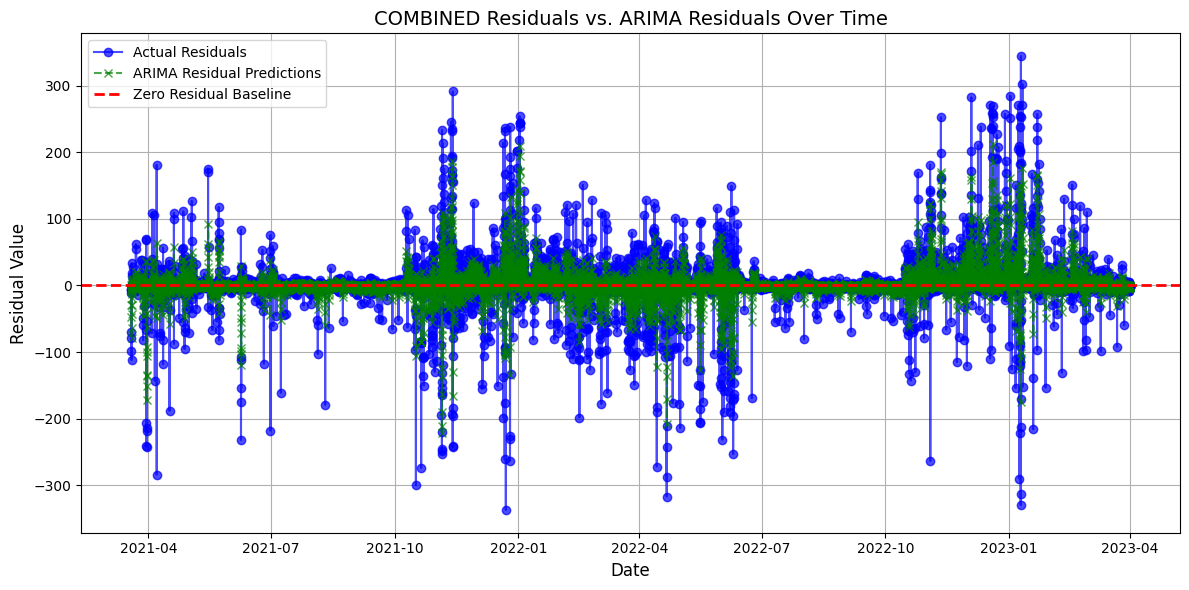

In [ ]:

df=pd.read_csv("/final_aqi_predictions (dl030).csv")


# Create a results DataFrame for plotting and analysis
results = pd.DataFrame({
    'From Date': pd.to_datetime(df['From Date']),
    'Residuals' : df['Residuals_Actual'],
    'ARIMA_Residuals': df['Residuals_ARIMA'],
})

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual residuals and ARIMA residuals against 'From Date'
plt.plot(results['From Date'], results['Residuals'],
         marker='o', linestyle='-', color='blue',
         alpha=0.7, label='Actual Residuals')
plt.plot(results['From Date'], results['ARIMA_Residuals'],
         marker='x', linestyle='--', color='green',
         alpha=0.7, label='ARIMA Residual Predictions')

# Add zero-residual baseline
plt.axhline(y=0, color='red', linestyle='--',
            linewidth=2, label='Zero Residual Baseline')

# Labels and title
plt.title('COMBINED Residuals vs. ARIMA Residuals Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual Value', fontsize=12)

# Improve readability
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

**SHAP ANALYSIS MEASURE PERFORMANCE OF POLLUTANTS**

For each pollutant, the code initializes and trains a new XGBoost Regressor model using temporal features to predict the pollutant's concentration. It then creates a shap.TreeExplainer for this trained model to interpret its predictions, calculating SHAP values for a data sample to quantify each feature's contribution. The mean absolute SHAP values are computed for each feature, providing an overall measure of its importance in predicting that pollutant. Finally, these results are compiled into a comparison table, which identifies the 'Most Impactful Feature' for each pollutant based on its SHAP score and offers a brief 'Reason' for its impact, thereby aiding in the understanding of the underlying temporal dynamics of each pollutant's concentration.



In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'shap' is installed
!pip install shap

# Re-load the data and features
# The dataframe 'df' and 'models' dictionary are expected to be available
# from previous execution, specifically cell VNmgWPCyODK7.
# If running this cell independently, uncomment and run the following:
df = pd.read_excel("/BR005_FILLED_AQI _2023.xlsx")
df['From Date'] = pd.to_datetime(df['From Date'])
df['year'] = df['From Date'].dt.year
df['month'] = df['From Date'].dt.month
df['day'] = df['From Date'].dt.day
df['hour'] = df['From Date'].dt.hour
features = ['year', 'month', 'day', 'hour']

pollutants_to_analyze = ["PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO2 (ug/m3)", "SO2 (ug/m3)", "CO (mg/m3)", "Ozone (ug/m3)"]
models = {}
from xgboost import XGBRegressor

# Train models for each pollutant
for col in pollutants_to_analyze:
    model = XGBRegressor(n_estimators=200, max_depth=5)
    model.fit(df[features], df[col])
    models[col] = model

print("Starting SHAP analysis...")

# List to store feature importances for each pollutant
all_feature_importances = []

# Loop through all pollutants for SHAP analysis
for pollutant_name in pollutants_to_analyze:
    if pollutant_name not in models:
        print(f"Error: Model for {pollutant_name} not found. Please ensure the model is trained.")
        continue

    model_to_explain = models[pollutant_name]
    X_data = df[features]

    # Create a SHAP explainer object
    explainer = shap.TreeExplainer(model_to_explain)

    # Calculate SHAP values for a sample of the data
    sample_size = min(1000, len(X_data)) # Use up to 1000 samples
    X_sample = X_data.sample(sample_size, random_state=42) if sample_size < len(X_data) else X_data

    shap_values = explainer.shap_values(X_sample)

    # Calculate mean absolute SHAP values for each feature
    mean_abs_shap_values = np.abs(shap_values).mean(0)

    # Store in a dictionary for this pollutant
    importance_dict = {'Pollutant': pollutant_name}
    for i, feature in enumerate(features):
        importance_dict[feature] = mean_abs_shap_values[i]

    all_feature_importances.append(importance_dict)

print("All SHAP analyses complete. Consolidating results into a table...")

# Create a DataFrame from the collected feature importances
feature_importance_df = pd.DataFrame(all_feature_importances)

# Set Pollutant as index for better readability
feature_importance_df = feature_importance_df.set_index('Pollutant')

# Now, create the comparison table as requested
comparison_data = []
for pollutant, row in feature_importance_df.iterrows():
    most_impactful_feature = row.idxmax()
    feature_score = row.max()

    reason = ""
    if most_impactful_feature == 'month':
        reason = "Monthly variations (seasonal patterns) are the most significant factor."
    elif most_impactful_feature == 'hour':
        reason = "Hourly patterns (e.g., traffic, industrial activity) are the most significant factor."
    elif most_impactful_feature == 'year':
        reason = "Yearly trends (long-term changes) are the most significant factor."
    elif most_impactful_feature == 'day':
        reason = "Daily variations (e.g., weekday/weekend, specific day events) are the most significant factor."

    comparison_data.append({
        'Pollutant': pollutant,
        'Most Impactful Feature': most_impactful_feature,
        'Feature Score (Mean Abs SHAP)': feature_score,
        'Reason': reason
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by Feature Score and add Rank
comparison_df = comparison_df.sort_values(by='Feature Score (Mean Abs SHAP)', ascending=False).reset_index(drop=True)
comparison_df['Rank'] = comparison_df.index + 1

# Reorder columns as requested: RANK, POLLUTANTS, FEATURE SCORE, REASON
comparison_df = comparison_df[['Rank', 'Pollutant', 'Most Impactful Feature', 'Feature Score (Mean Abs SHAP)', 'Reason']]

print("\n--- SHAP Feature Impact Comparison Table ---")
display(comparison_df)


Starting SHAP analysis...
All SHAP analyses complete. Consolidating results into a table...

--- SHAP Feature Impact Comparison Table ---


,Rank,Pollutant,Most Impactful Feature,Feature Score (Mean Abs SHAP),Reason
0,1,PM10 (ug/m3),month,73.989883,Monthly variations (seasonal patterns) are the...
1,2,PM2.5 (ug/m3),month,42.781948,Monthly variations (seasonal patterns) are the...
2,3,NO2 (ug/m3),month,23.807598,Monthly variations (seasonal patterns) are the...
3,4,Ozone (ug/m3),hour,12.988946,"Hourly patterns (e.g., traffic, industrial act..."
4,5,SO2 (ug/m3),month,2.929385,Monthly variations (seasonal patterns) are the...
5,6,CO (mg/m3),month,0.441471,Monthly variations (seasonal patterns) are the...


THANKYOU